# Import

In [96]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tikzplotlib

# Results directory

In [97]:
RESULTS_DIR = Path("results/time_per_it_5")

# File

In [98]:
DATA = RESULTS_DIR / "compromise_results.csv"
COLLECTIVE = RESULTS_DIR / "collective_results.csv"
PATH = RESULTS_DIR / "path_results.csv"

# Read files

In [99]:
df = pd.read_csv(DATA)
df_collective = pd.read_csv(COLLECTIVE)
df_path = pd.read_csv(PATH)

In [100]:
df_bis = pd.read_csv(Path("results/time_per_it_4") / "compromise_results.csv")

In [101]:
df_collective

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mie,Mie_config,Mie_id,Mc_id,Nb_Mcp,Path,P_id,It,Time,Objective
0,3,100,1,1,1,2,0,1,10,True,...,False,NaN,1,1,1,False,1,0,0.117805,0.0
1,3,100,2,1,2,2,0,2,10,True,...,False,NaN,2,2,1,True,2,0,0.143498,0.0
2,3,100,1,1,1,2,0,1,10,True,...,False,NaN,1,1,1,True,1,0,0.147199,0.0
3,3,100,2,1,2,2,0,2,10,True,...,False,NaN,2,2,1,False,2,0,0.193008,0.0
4,3,100,3,1,3,2,0,3,10,True,...,False,NaN,3,3,1,True,3,0,0.218144,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4492,4,100,34,3,34,2,0,34,30,True,...,False,NaN,34,34,1,False,34,0,300.000642,inf
4493,4,100,35,3,35,2,0,35,30,True,...,False,NaN,35,35,1,False,35,0,300.000861,inf
4494,3,100,47,1,47,2,0,47,50,True,...,False,NaN,47,47,1,True,47,230,83.745397,44.0
4495,4,100,36,3,36,2,0,36,30,True,...,False,NaN,36,36,1,False,36,0,300.000931,inf


In [102]:
df_collective

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mie,Mie_config,Mie_id,Mc_id,Nb_Mcp,Path,P_id,It,Time,Objective
0,3,100,1,1,1,2,0,1,10,True,...,False,NaN,1,1,1,False,1,0,0.117805,0.0
1,3,100,2,1,2,2,0,2,10,True,...,False,NaN,2,2,1,True,2,0,0.143498,0.0
2,3,100,1,1,1,2,0,1,10,True,...,False,NaN,1,1,1,True,1,0,0.147199,0.0
3,3,100,2,1,2,2,0,2,10,True,...,False,NaN,2,2,1,False,2,0,0.193008,0.0
4,3,100,3,1,3,2,0,3,10,True,...,False,NaN,3,3,1,True,3,0,0.218144,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4492,4,100,34,3,34,2,0,34,30,True,...,False,NaN,34,34,1,False,34,0,300.000642,inf
4493,4,100,35,3,35,2,0,35,30,True,...,False,NaN,35,35,1,False,35,0,300.000861,inf
4494,3,100,47,1,47,2,0,47,50,True,...,False,NaN,47,47,1,True,47,230,83.745397,44.0
4495,4,100,36,3,36,2,0,36,30,True,...,False,NaN,36,36,1,False,36,0,300.000931,inf


In [103]:
df_path

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mie_id,Mc_id,Nb_Mcp,Path,P_id,It,Dm_id,Time,Length,Model_Length
0,3,100,2,1,2,2,0,2,10,True,...,2,2,1,True,2,0,0,0.000003,0.0,2.0
1,3,100,4,1,4,2,0,4,10,True,...,4,4,1,True,4,0,1,0.624163,2.0,3.0
2,3,100,1,1,1,2,0,1,10,True,...,1,1,1,True,1,0,0,0.000003,0.0,2.0
3,3,100,1,1,1,2,0,1,10,True,...,1,1,1,True,1,0,1,0.000004,0.0,2.0
4,3,100,0,1,0,2,0,0,10,True,...,0,0,1,True,0,0,0,0.000003,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3497,3,100,47,1,47,2,0,47,50,True,...,47,47,1,True,47,229,0,1.176842,1.0,29.0
3498,3,100,47,1,47,2,0,47,50,True,...,47,47,1,True,47,230,0,0.571245,1.0,24.0
3499,3,100,47,1,47,2,0,47,50,True,...,47,47,1,True,47,230,1,1.322329,3.0,31.0
3500,4,100,40,3,40,2,0,40,30,True,...,40,40,1,True,40,0,0,0.000003,0.0,2.0


# New attributes

In [104]:
df["Gen"] = np.array(["Homogene", "Heterogene"])[df["Group"] % 2]
df["Accept"] = np.array(["Conservative", "Tolerant"])[df["Group"] % 2]

df["Changes_Prop"] = df["Changes"] / (df["N_bc"] * df["Group_size"])

df_collective["Objective_Prop"] = df_collective["Objective"] / df_collective["N_bc"]

In [105]:
# from math import inf


# df_collective.loc[df_collective["Objective"] == inf, "Time"] = 600

# Filter

In [106]:
# dff = df[df["Fitness_train"] == 1]
# dff = df[df["N_tr"].isin([10, 20, 30, 80, 90, 100])]
# dff = df[df["N_tr"] % 20 == 0]
dff = df
dff = dff[~df["Mie"]]
dff = dff.drop(columns=["Mie", "Mie_id"])
# dff = dff[dff["Group_size"] == 2]
dff = dff[dff["Ko"] <= 3]
dff = dff[dff["Gen"] == "Homogene"]
# dff = dff[dff["Path"]]
# dff = dff[dff["Compromise"]]

In [107]:
# dff.loc[dff["Time"] > 300, "Compromise"] = False

In [108]:
dff

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Nb_Mcp,Path,P_id,Compromise,Time,It,Changes,Gen,Accept,Changes_Prop
0,3,100,4,1,4,2,0,4,10,True,...,1,False,4,True,0.087626,1,3,Homogene,Conservative,0.15
1,3,100,3,1,3,2,0,3,10,True,...,1,False,3,True,0.100280,1,2,Homogene,Conservative,0.10
2,3,100,2,1,2,2,0,2,10,True,...,1,False,2,True,0.099727,1,0,Homogene,Conservative,0.00
3,3,100,8,1,8,2,0,8,10,True,...,1,False,8,True,0.097191,1,0,Homogene,Conservative,0.00
4,3,100,1,1,1,2,0,1,10,True,...,1,True,1,True,0.783932,1,0,Homogene,Conservative,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2750,4,100,35,3,35,2,0,35,30,True,...,1,True,35,False,0.479491,1,0,Homogene,Conservative,0.00
2751,4,100,34,3,34,2,0,34,30,True,...,1,False,34,False,0.641932,1,0,Homogene,Conservative,0.00
2752,4,100,35,3,35,2,0,35,30,True,...,1,False,35,False,0.667805,1,0,Homogene,Conservative,0.00
2753,4,100,36,3,36,2,0,36,30,True,...,1,False,36,False,0.495523,1,0,Homogene,Conservative,0.00


# Merge data

In [109]:
# df = pd.merge(
#     df_mip,
#     df_path,
#     how="left",
#     on=[
#         "M",
#         "N_tr",
#         "Atr_id",
#         "Ko",
#         "Mo_id",
#         "Group_size",
#         "Group",
#         "Mi_id",
#         "N_bc",
#         "Same_alt",
#         "D_id",
#         "Config",
#         "Mc_id",
#         "Path",
#         "P_id",
#         "It"
#     ],
#     suffixes=["_mip", "_path"],
# )


df_compromise_path = dff[dff["Path"]]
df_compromise_path = df_compromise_path[df_compromise_path["Compromise"]]
df_compromise_path_index = df_compromise_path.drop(
    columns=["Path", "Compromise", "Time", "It", "Changes", "Changes_Prop"]
)
df_compromise_no_path = dff[~dff["Path"]]
df_compromise_no_path = df_compromise_no_path[df_compromise_no_path["Compromise"]]
df_compromise_no_path_index = df_compromise_no_path.drop(
    columns=["Path", "Compromise", "Time", "It", "Changes", "Changes_Prop"]
)

df_compromise_index = pd.merge(
    df_compromise_path_index,
    df_compromise_no_path_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
)

df_compromise_path = pd.merge(
    df_compromise_path,
    df_compromise_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
    suffixes=["", ""],
)

df_compromise_no_path = pd.merge(
    df_compromise_no_path,
    df_compromise_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
    suffixes=["", ""],
)

# df_compromise = pd.merge(
#     df_compromise_path,
#     df_compromise_no_path,
#     how="inner",
#     on=[
#         "M",
#         "N_tr",
#         "Atr_id",
#         "Ko",
#         "Mo_id",
#         "Group_size",
#         "Group",
#         "Mi_id",
#         "N_bc",
#         "Same_alt",
#         "D_id",
#         "Config",
#         "Mie",
#         "P_id",
#         "Mie_id",
#         "Mc_id",
#         "P_id",
#         "Gen",
#         "Accept"
#     ],
#     suffixes=["_path", "_no_path"],
# )

df_compromise = pd.concat([df_compromise_path, df_compromise_no_path])

df_compromise

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Changes,Gen,Accept,Changes_Prop,Method_x,Mie_config_x,Nb_Mcp_x,Method_y,Mie_config_y,Nb_Mcp_y
0,3,100,1,1,1,2,0,1,10,True,...,0,Homogene,Conservative,0.0,mip,NaN,1,mip,NaN,1
1,3,100,2,1,2,2,0,2,10,True,...,0,Homogene,Conservative,0.0,mip,NaN,1,mip,NaN,1
2,3,100,8,1,8,2,0,8,10,True,...,0,Homogene,Conservative,0.0,mip,NaN,1,mip,NaN,1
3,3,100,3,1,3,2,0,3,10,True,...,2,Homogene,Conservative,0.1,mip,NaN,1,mip,NaN,1
4,3,100,10,1,10,2,0,10,10,True,...,0,Homogene,Conservative,0.0,mip,NaN,1,mip,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
808,4,100,22,3,22,2,0,22,30,True,...,0,Homogene,Conservative,0.0,mip,NaN,1,mip,NaN,1
809,4,100,25,3,25,2,0,25,30,True,...,0,Homogene,Conservative,0.0,mip,NaN,1,mip,NaN,1
810,4,100,29,3,29,2,0,29,30,True,...,0,Homogene,Conservative,0.0,mip,NaN,1,mip,NaN,1
811,4,100,26,3,26,2,0,26,30,True,...,0,Homogene,Conservative,0.0,mip,NaN,1,mip,NaN,1


# Plot

Text(0.5, 0.98, 'Proportion of instances reaching compromise (6 CPUs)')

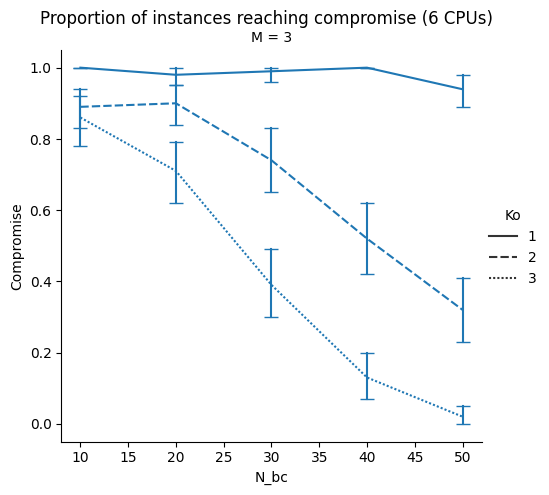

In [122]:
g = sns.relplot(
    dff[dff["M"] == 3],
    x="N_bc",
    y="Compromise",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Proportion of instances reaching compromise (6 CPUs)")

Text(0.5, 0.98, 'Proportion of instances reaching compromise (18 CPUs)')

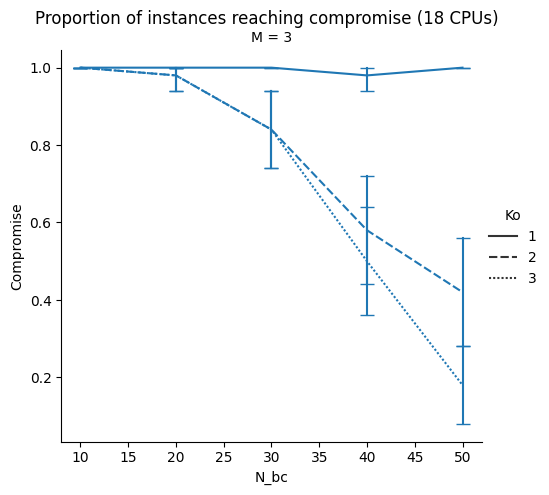

In [121]:
g = sns.relplot(
    df_bis,
    x="N_bc",
    y="Compromise",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Proportion of instances reaching compromise (18 CPUs)")

Text(0.5, 0.98, 'Computing time of instances reaching compromise')

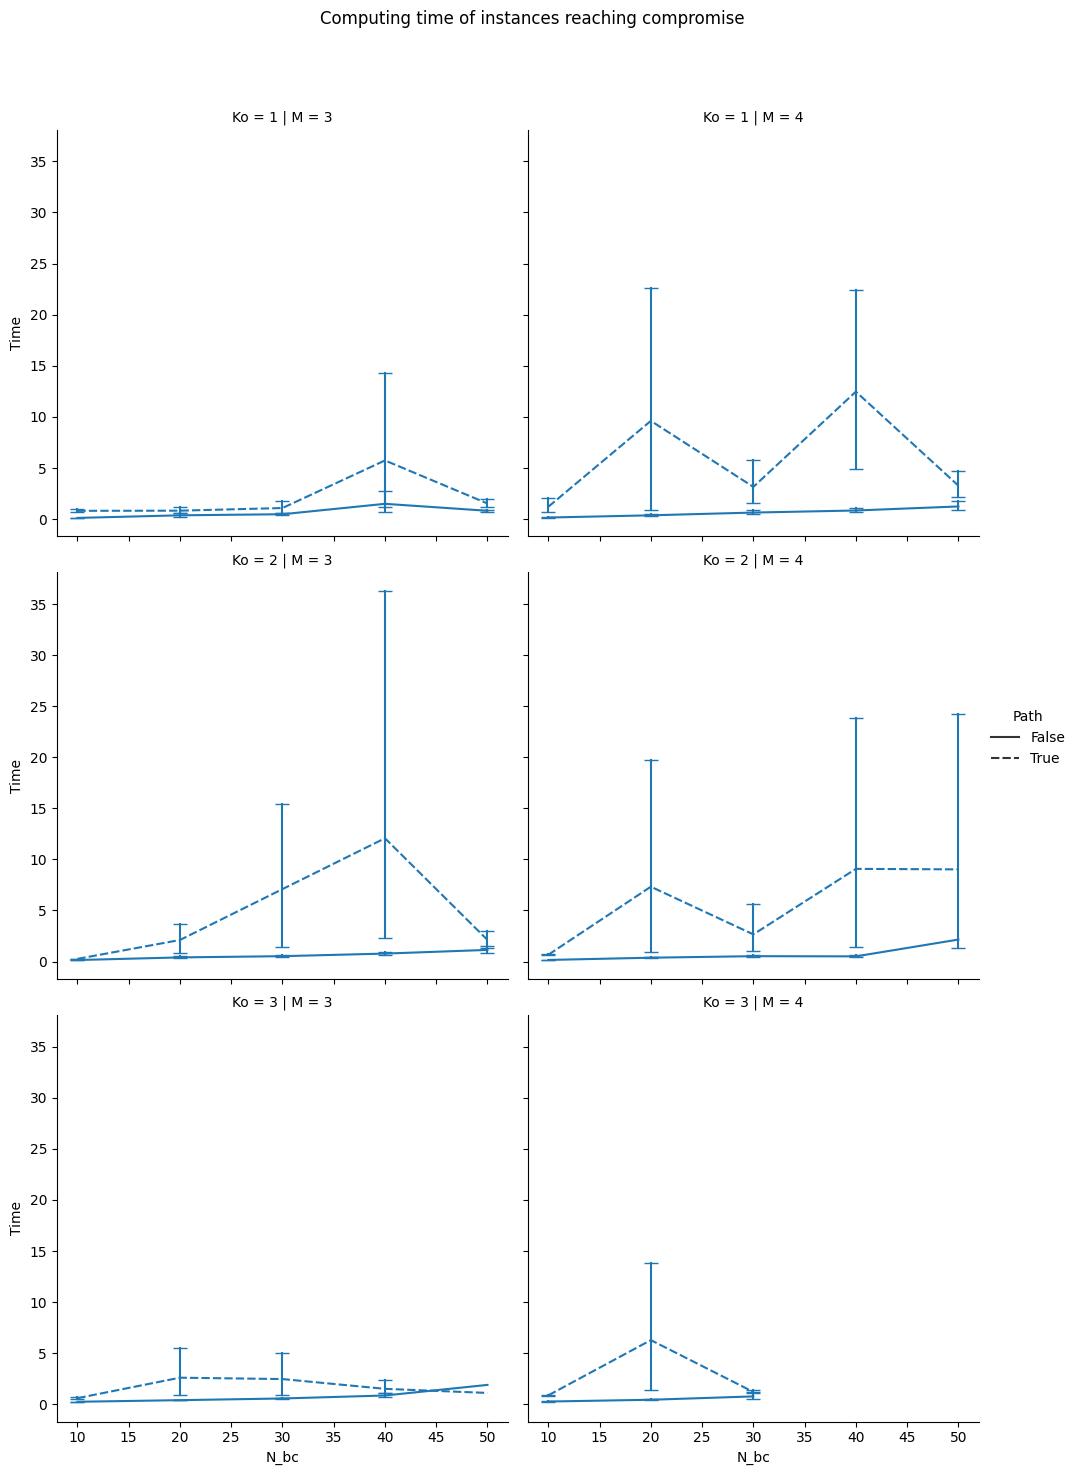

In [118]:
g = sns.relplot(
    dff[dff["Compromise"]],
    x="N_bc",
    y="Time",
    row="Ko",
    col="M",
    style="Path",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time of instances reaching compromise")

Text(0.5, 0.98, 'Computing time for collective model (MILP)')

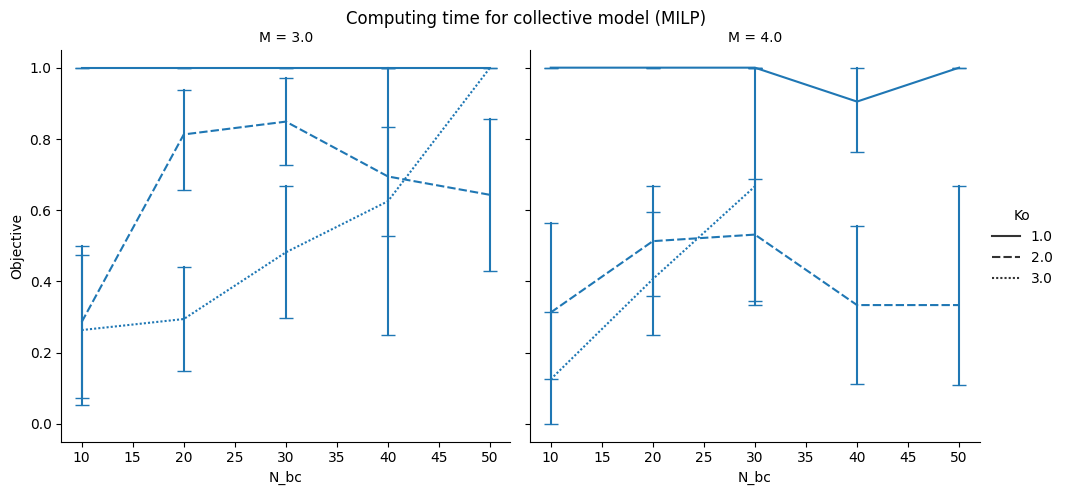

In [112]:
g = sns.relplot(
    df_collective[df_collective["It"] == 1],
    x="N_bc",
    y=df_collective["Objective"] < inf,
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time for collective model (MILP)")

Text(0.5, 0.98, 'Computing time for collective model (MILP)')

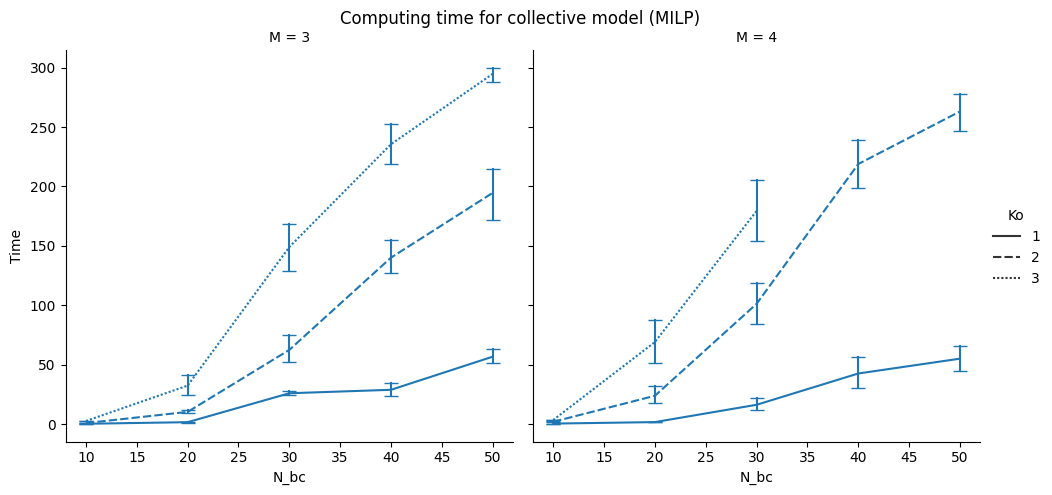

In [113]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Time",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time for collective model (MILP)")

Text(0.5, 0.98, 'Computing time for preference path')

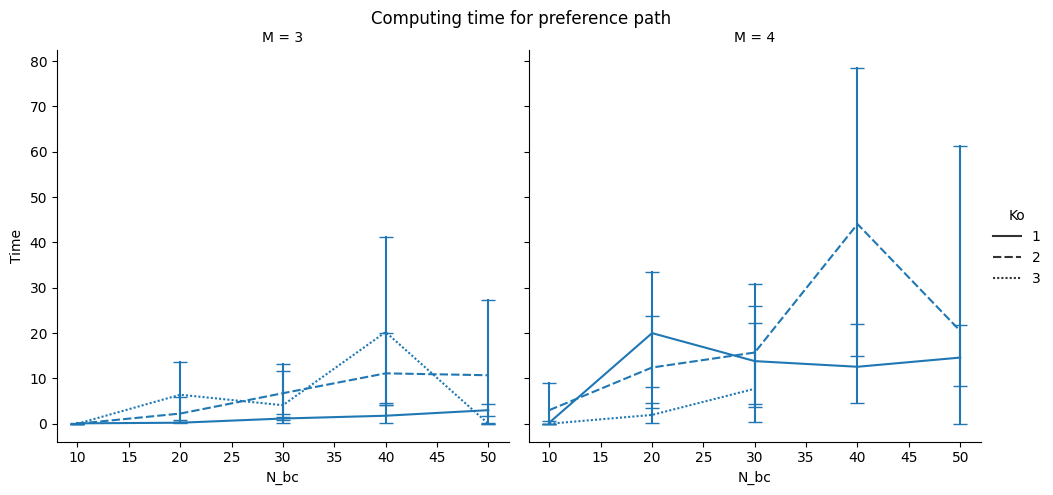

In [114]:
g = sns.relplot(
    df_path,
    x="N_bc",
    y="Time",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time for preference path")

Text(0.5, 0.98, 'Number of iterations')

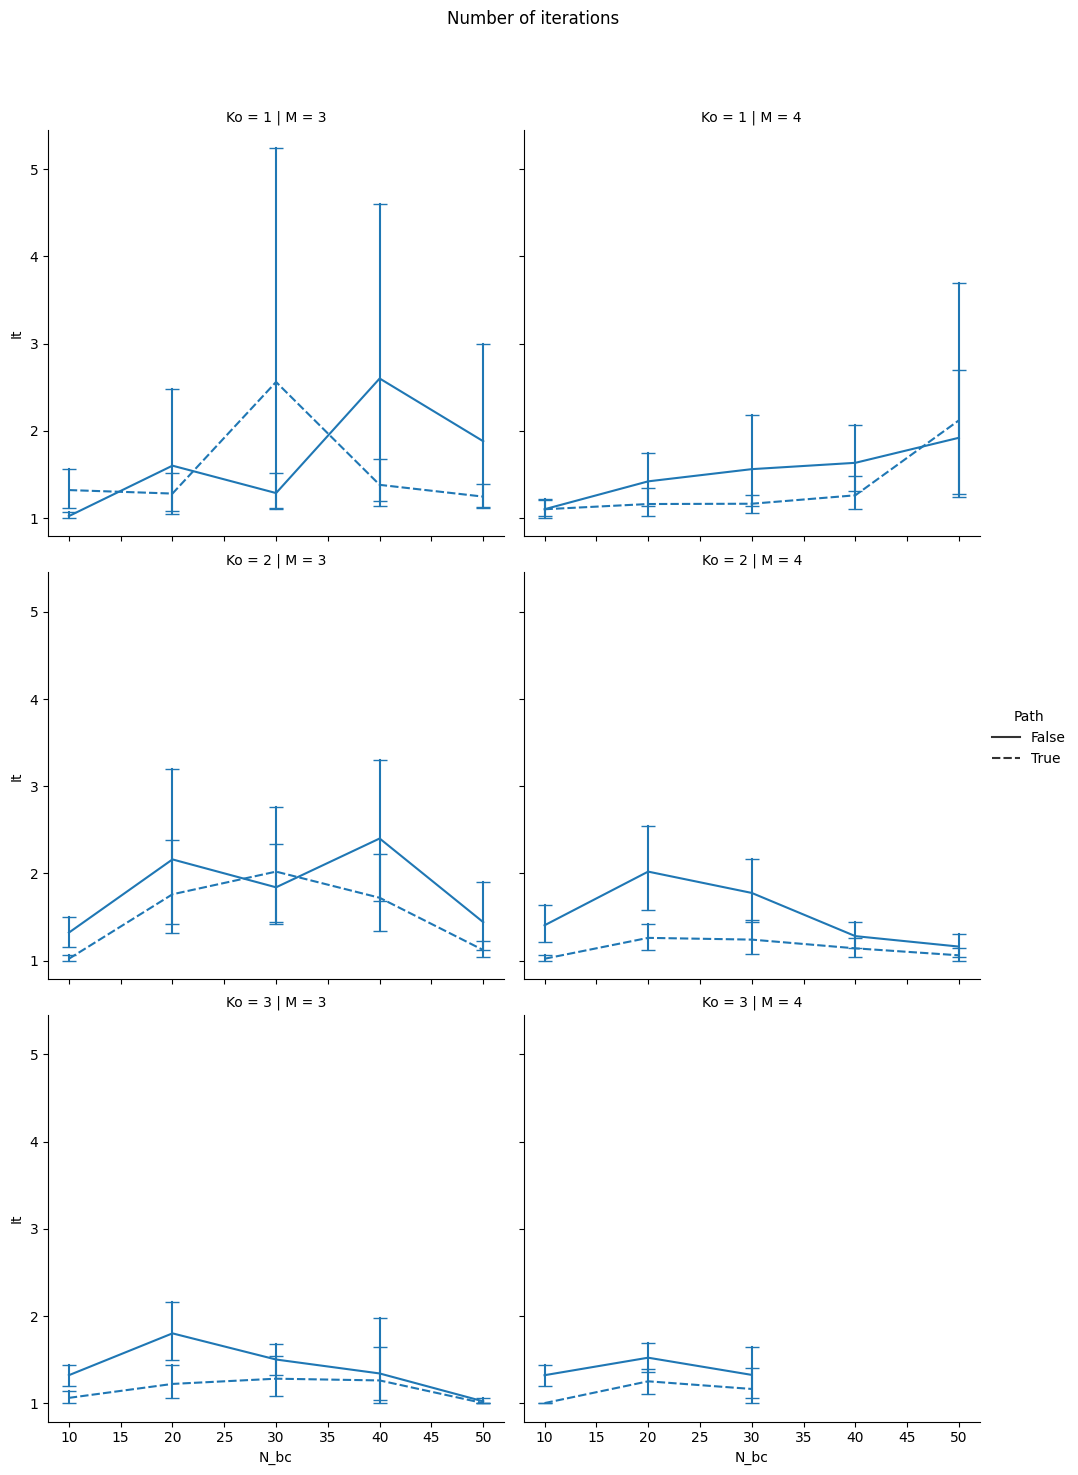

In [115]:
g = sns.relplot(
    dff,
    x="N_bc",
    y="It",
    row="Ko",
    col="M",
    style="Path",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Number of iterations")

Text(0.5, 0.98, 'Max number of comparisons to change for DMs')

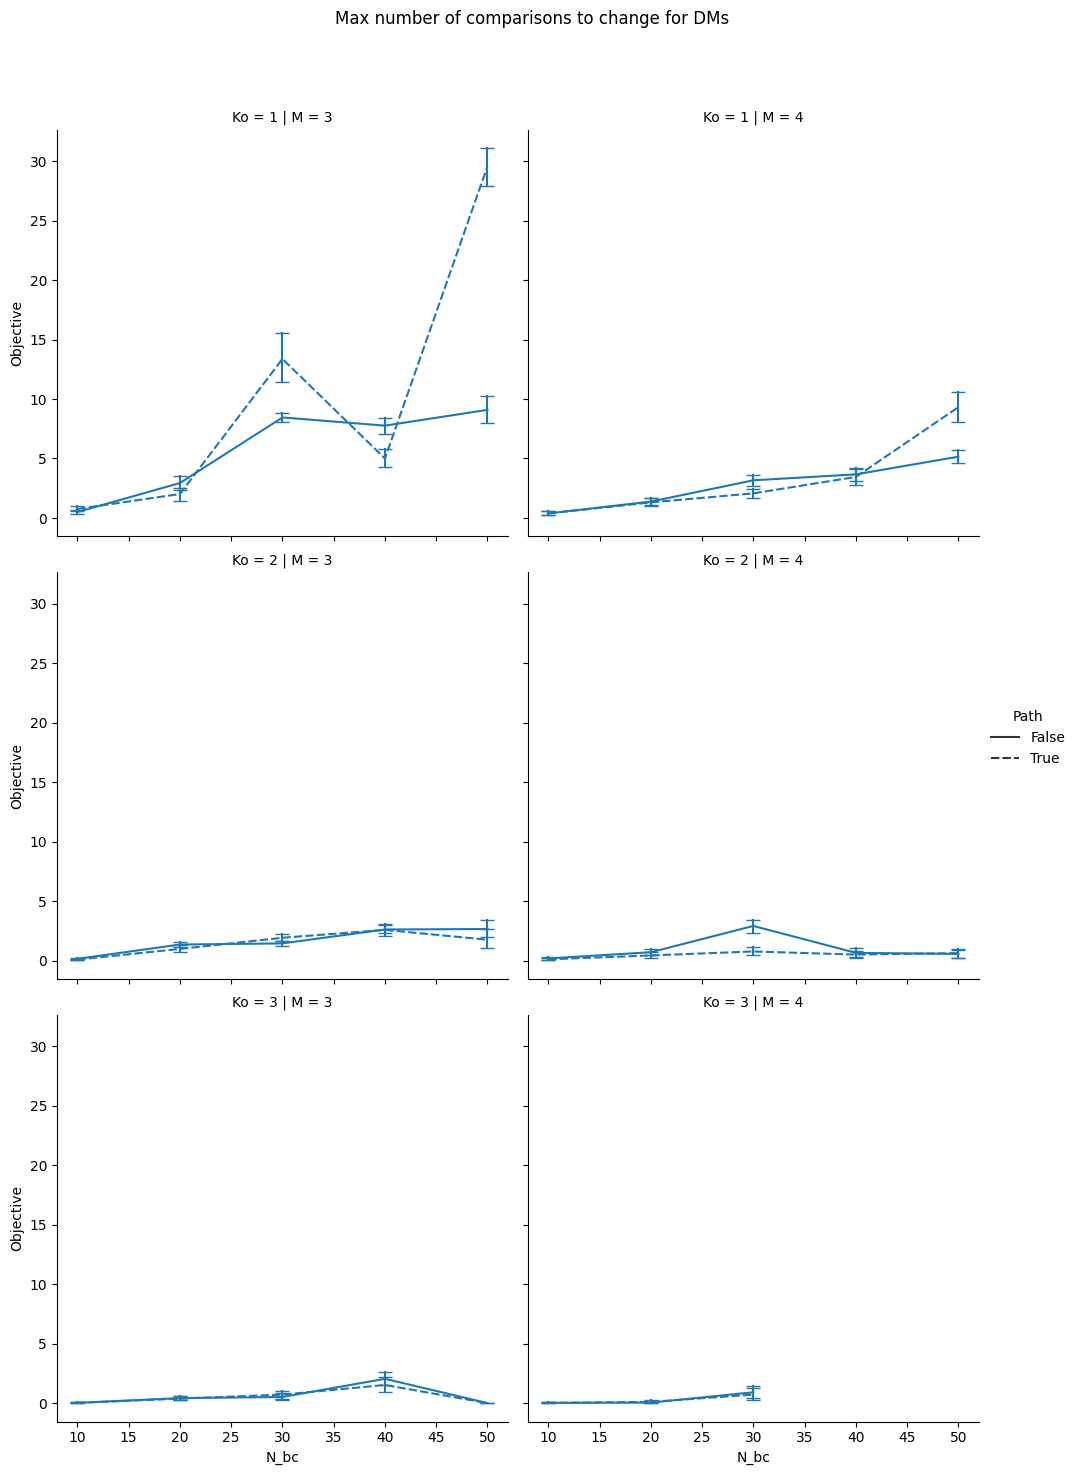

In [116]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Objective",
    row="Ko",
    col="M",
    style="Path",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Max number of comparisons to change for DMs")

Text(0.5, 0.98, 'Max proportion of comparisons to change for DMs')

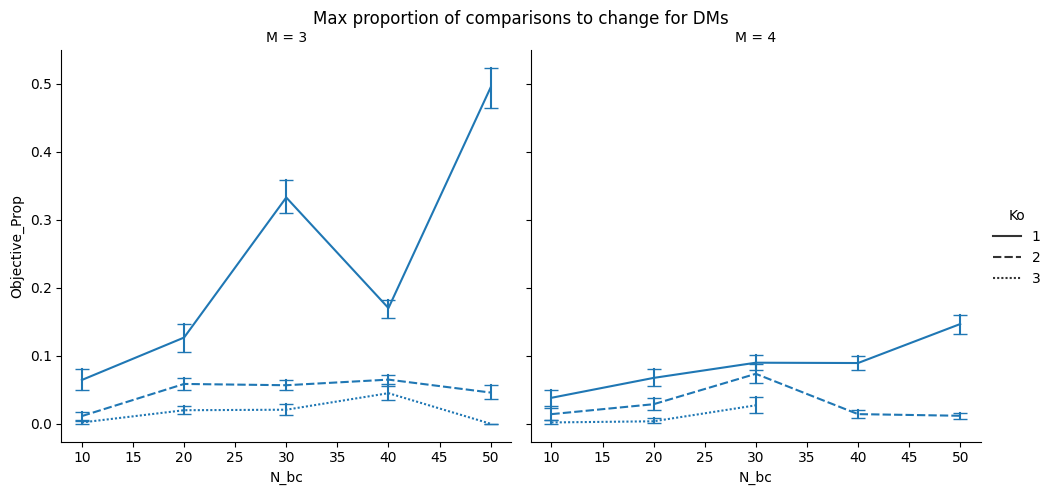

In [117]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Objective_Prop",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Max proportion of comparisons to change for DMs")

Text(0.5, 0.98, 'Number of iterations')

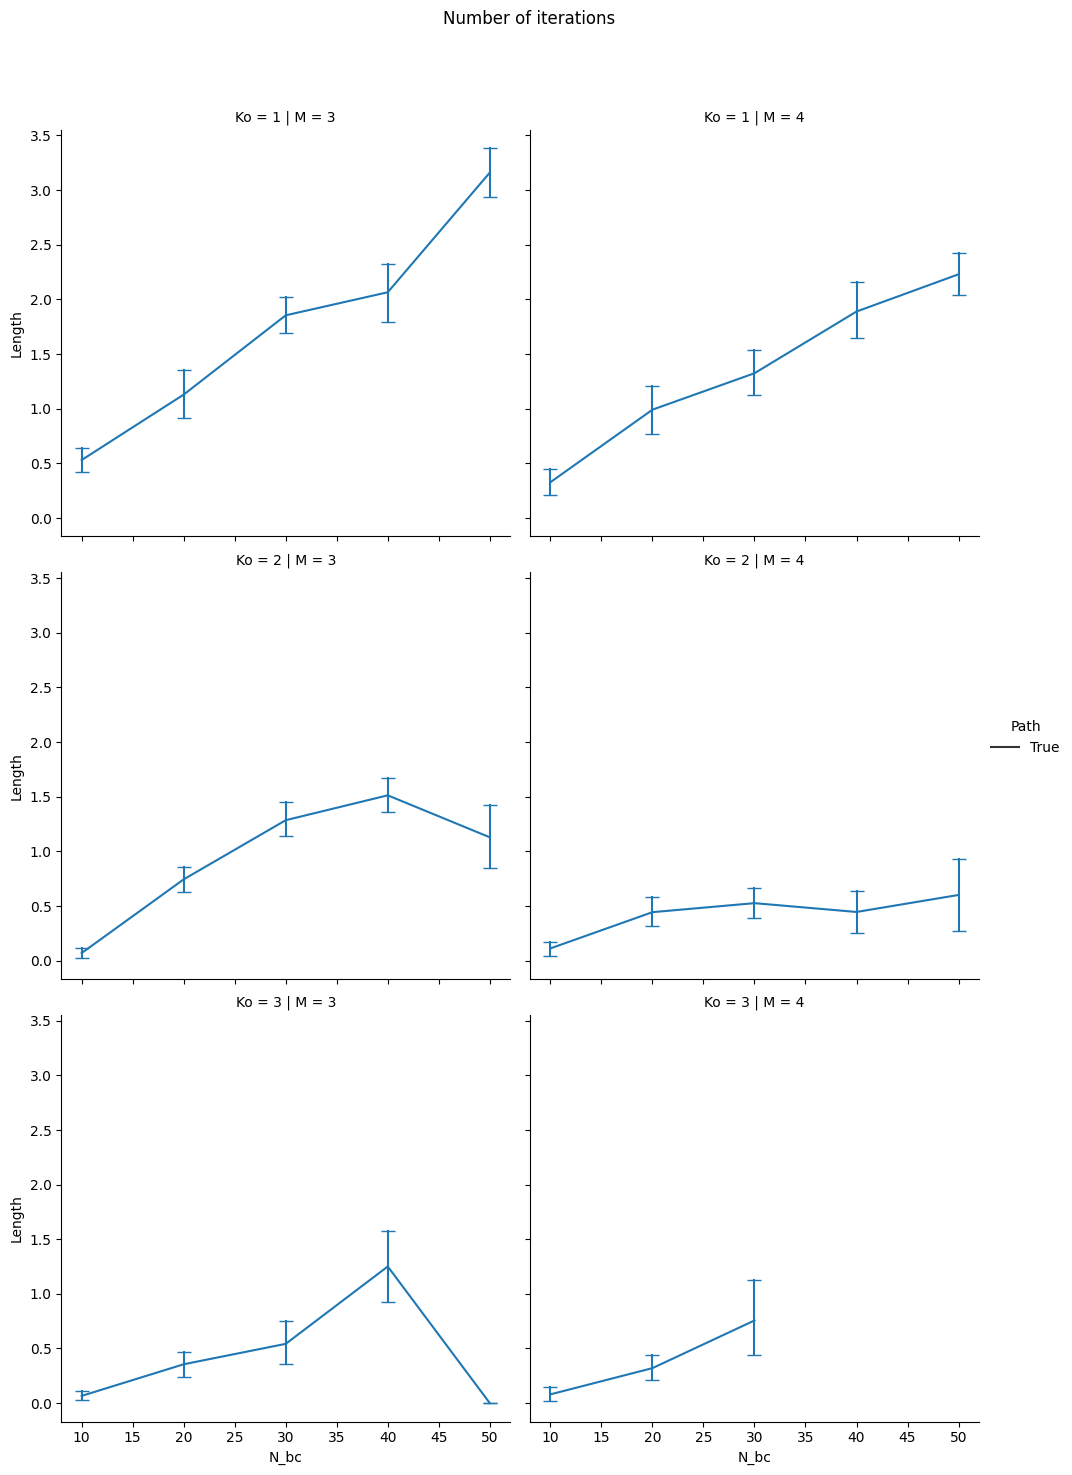

In [123]:
g = sns.relplot(
    df_path,
    x="N_bc",
    y="Length",
    row="Ko",
    col="M",
    style="Path",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Number of iterations")